# CNN vs CNN-ViT Hybrid Architectures for Satellite Crop Classification

## Notebook 04: Cross-Framework & Cross-Architecture Comparative Analysis

---

### Table of Contents

- [1. Objective and Comparison Design](#1-objective-and-comparison-design)
  - [1.1 Goal of This Notebook](#11-goal-of-this-notebook)
  - [1.2 Comparison Dimensions](#12-comparison-dimensions)
- [2. Experimental Summary](#2-experimental-summary)
  - [2.1 Analysis Preparation](#21-analysis-preparation)
  - [2.2 Unified Metadata Comparison Table](#22-unified-metadata-comparison-table)
- [3. Learning Dynamics Analysis](#3-learning-dynamics-analysis)
  - [3.1 CNN Baseline:Keras vs PyTorch](#31-cnn-baseline-keras-vs-pytorch)
  - [3.2 CNN–ViT Hybrid:Keras vs PyTorch](#32-cnn–vit-hybrid-keras-vs-pytorch)
  - [3.3 Architecture Comparison (Baseline vs Hybrid)](#33-architecture-comparison-baseline-vs-hybrid)
  - [3.4 Learning Dynamics Overall Interpretation](#34-learning-dynamics-overall-interpretation)
- [4. Generalization Analysis](#4-generalization-analysis)
  - [4.1 Generalization Gap Over Epochs](#41-generalization-gap-over-epochs)
  - [4.2 Gap at Best Epoch (Table)](#42-gap-at-best-epoch-table)
- [5. Final Performance Comparison](#5-final-performance-comparison)
  - [5.1 Final Metrics Table](#51-final-metrics-table)
  - [5.2 Final Model Evaluation](#52-final-model-evaluation)
  - [5.3 ROC Curve Comparison](#53-roc-curve-comparison)
  - [5.4 Confusion Matrix Analysis](#54-confusion-matrix-analysis)
  - [5.5 Interpreting Results](#55-interpreting-results)
- [6. Efficiency & Computational Cost](#6-efficiency--computational-cost)
  - [6.1 Parameter Count Comparison](#61-parameter-count-comparison)
  - [6.2 Training Time Comparison](#62-training-time-comparison)
  - [6.3 Model Size Comparison](#63-model-size-comparison)
  - [6.4 Performance vs Efficiency Tradeoff](#64-performance-vs-efficiency-tradeoff)
- [7. Cross-Dimension Analysis](#7-cross-dimension-analysis)
  - [7.1. Framework Effect](#71-framework-effect)
  - [7.2. Architecture Effect](#72-architecture-effect)
  - [7.3. Interaction Effect](#73-interaction-effect)
- [8. Discussion](#8-discussion)
  - [8.1. Predictive Performance Summary](#81-predictive-performance-summary)
  - [8.2. Generalization Behavior](#82-generalization-behavior)
  - [8.3. Efficiency Tradeoffs](#83-efficiency-tradeoffs)
  - [8.4. Practical Recommendation](#84-practical-recommendation)
- [9. Limitations](#9-limitations)
- [10. Conclusion](#10-conclusion)
- [Author](#author)
- [Version History](#version-history)

---

## 1. Objective and Comparison Design

This notebook concludes the project by consolidating and comparing all trained models for binary classification of AnnualCrop vs PermanentCrop from EuroSAT imagery, under a controlled and reproducible experimental setup.

It evaluates:

* CNN Baseline Keras (CNN_Keras)
* CNN Baseline PyTorch (CNN_Torch)
* CNN–ViT Hybrid Keras (Hybrid_Keras)
* CNN–ViT Hybrid PyTorch (Hybrid_PyTorch)

The purpose is to perform a comparative analysis using identical data splits, seeds, and preprocessing pipelines.

### 1.1 Goal of This Notebook

The objective is to quantify and interpret differences across:

* Architecture (CNN vs CNN–ViT Hybrid)
* Framework (Keras-TensorFlow vs PyTorch)

The notebook provides:

* Convergence behavior analysis
* Generalization gap assessment
* Final metric comparison (Accuracy, Precision, Recall, F1, AUC, Loss)
* ROC and confusion matrix evaluation
* Efficiency comparison (parameters, training time, model size)
* Performance–efficiency trade-off analysis

All comparisons are conducted under:

* Identical dataset partitions
* Fixed random seed (7331)
* Equivalent preprocessing pipelines
* Centralized hyperparameters

This ensures observed differences reflect architectural or framework effects rather than experimental inconsistencies.

### 1.2 Comparison Dimensions

The experimental structure follows a 2 × 2 design.

#### 1.2.1 Architecture Effect

Comparison between:

* CNN baseline
* CNN–ViT Hybrid

Evaluated in terms of:

* Convergence dynamics
* Predictive performance
* Generalization behavior
* Computational cost

This isolates the impact of integrating Transformer-based attention into a convolutional backbone.

#### 1.2.2 Framework Effect

Comparison between:

* Keras (TensorFlow backend)
* PyTorch

Evaluated in terms of:

* Optimization trajectory
* Metric stability
* Training efficiency
* Model size
* Reproducibility consistency

This isolates framework-level implementation differences.

#### 1.2.3 Interaction Effect

By combining both dimensions, the analysis determines:

* Whether architectural gains are consistent across frameworks
* Whether framework differences depend on architecture
* Whether performance hierarchy is stable across ecosystems

This structured comparison enables clear attribution of performance differences to architecture, framework, or their interaction.

## 2. Experimental Summary

This section prepares all trained artifacts for unified comparison.
Models, histories, and metadata are loaded exactly as produced in Notebooks 2 and 3.

### 2.1 Analysis Preparation

The environment is configured to ensure clean execution and deterministic evaluation.

Key steps:

* Suppress unnecessary TensorFlow logging
* Import shared modular components (`src`)
* Load:

  * Model weight files (.keras / .pth)
  * Training histories (.json)
  * Training metadata (.json)

To guarantee evaluation consistency, the exact same data pipeline from Notebook 1 is reconstructed:

* `SEED = 7331`
* Balanced binary dataset (2500 samples per class)
* Stratified 80/20 split
* Image size: (64, 64)
* Batch size: 128

This ensures:

* Identical validation set
* Identical preprocessing
* No data leakage
* Strict comparability across all four models

The dataset partitions used here are therefore identical to those used during training.

In [1]:
#Supressing Unnecessary TensorFlow Warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

# Importing
import sys
sys.path.append("/kaggle/input/datasets/filipebraiman/cnn-vit-src-modules")

from src.data import *
from src.baseline_models import *
from src.hybrid_models import *
from src.evaluation_utils import *
from src.model_load_eval import *

# Defining paths
sys.path.append("/kaggle/input/datasets/filipebraiman/baseline-models-training-info")
sys.path.append("/kaggle/input/datasets/filipebraiman/hybrid-models-training-info")

keras_baseline_history="/kaggle/input/datasets/filipebraiman/baseline-models-training-info/keras_cnn_baseline_history.json"
torch_baseline_history="/kaggle/input/datasets/filipebraiman/baseline-models-training-info/pytorch_cnn_baseline_history.json"
keras_baseline_metadata="/kaggle/input/datasets/filipebraiman/baseline-models-training-info/keras_cnn_baseline_metadata.json"
torch_baseline_metadata="/kaggle/input/datasets/filipebraiman/baseline-models-training-info/pytorch_cnn_baseline_metadata.json"
keras_hybrid_history="/kaggle/input/datasets/filipebraiman/hybrid-models-training-info/keras_hybrid_history.json"
torch_hybrid_history="/kaggle/input/datasets/filipebraiman/hybrid-models-training-info/pytorch_hybrid_history.json"
keras_hybrid_metadata="/kaggle/input/datasets/filipebraiman/hybrid-models-training-info/keras_hybrid_metadata.json"
torch_hybrid_metadata="/kaggle/input/datasets/filipebraiman/hybrid-models-training-info/pytorch_hybrid_metadata.json"

metadata_paths = [
    "/kaggle/input/datasets/filipebraiman/baseline-models-training-info/keras_cnn_baseline_metadata.json",
    "/kaggle/input/datasets/filipebraiman/baseline-models-training-info/pytorch_cnn_baseline_metadata.json",
    "/kaggle/input/datasets/filipebraiman/hybrid-models-training-info/keras_hybrid_metadata.json",
    "/kaggle/input/datasets/filipebraiman/hybrid-models-training-info/pytorch_hybrid_metadata.json"
]

keras_baseline="/kaggle/input/datasets/filipebraiman/baseline-models-training-info/keras_cnn_baseline.keras"
torch_baseline="/kaggle/input/datasets/filipebraiman/baseline-models-training-info/pytorch_cnn_baseline.pth"
keras_hybrid="/kaggle/input/datasets/filipebraiman/hybrid-models-training-info/keras_hybrid.keras"
torch_hybrid="/kaggle/input/datasets/filipebraiman/hybrid-models-training-info/pytorch_hybrid.pth"

# Setting data pipeline for model loading and evaluation
SEED = 7331
BASE_DIR = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT"

CLASS_MAP = {
    "AnnualCrop": 0,
    "PermanentCrop": 1
}

SAMPLES_PER_CLASS = 2500
VAL_SPLIT = 0.2

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 128

set_global_seed(SEED)

files, labels = build_balanced_binary_dataset(
    base_dir=BASE_DIR,
    class_map=CLASS_MAP,
    samples_per_class=SAMPLES_PER_CLASS,
    seed=SEED
)

train_files, val_files, train_labels, val_labels = build_stratified_split(
    files,
    labels,
    val_split=VAL_SPLIT,
    seed=SEED
)

train_ds_keras, val_ds_keras = build_keras_datasets(
    train_files,
    train_labels,
    val_files,
    val_labels,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

train_loader, val_loader = build_torch_dataloaders(
    train_files,
    train_labels,
    val_files,
    val_labels,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

E0000 00:00:1772568858.108107      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772568858.170639      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772568858.678122      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772568858.678160      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772568858.678163      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772568858.678165      24 computation_placer.cc:177] computation placer already registered. Please check linka

### 2.2 Unified Metadata Comparison Table

All training metadata files are aggregated into a single structured dataframe.

This produces a side-by-side summary of:

* Architecture
* Framework
* Best validation performance
* Training duration
* Parameter count
* Model size
* Hardware context
* Seed configuration

This confirms that all four models were trained under strictly controlled and equivalent experimental conditions.

The following sections analyze learning behavior, generalization, and performance–efficiency trade-offs using these consolidated artifacts.

In [2]:
df_metadata = build_metadata_dataframe(metadata_paths, 
                                       save_path="/kaggle/working/metadata_comparison.csv"
                                      )
df_metadata

,CNN_Keras,CNN_Torch,Hybrid_Keras,Hybrid_Torch
architecture,CNN,CNN,Hybrid,Hybrid
framework,Keras,Torch,Keras,Torch
best_val_accuracy,0.967,0.967,0.973,0.971
best_val_loss,0.087481,0.106039,0.074835,0.096673
best_epoch,38,31,22,41
epochs_ran,48,41,32,50
param_count,456673,455201,795617,794145
batch_size,128,128,128,128
learning_rate,0.001,0.001,0.001,0.001
train_dataset_size,4000,4000,4000,4000


## 3. Learning Dynamics Analysis

This section analyzes **validation Accuracy, AUC, and Loss** across epochs to compare optimization behavior, convergence speed, and stability.

### 3.1 CNN Baseline: Keras vs PyTorch

**Early phase**

* **Keras** improves immediately (Acc 0.63 → 0.86 by epoch 6).
* **PyTorch** remains at chance level (0.50) for the first 4 epochs.
* PyTorch shows very high initial validation loss (2.13 → 7.66), indicating unstable early optimization.
* Keras reaches high AUC (>0.94) by **epoch 5**; PyTorch by **epoch 11**.

**Mid training**

* PyTorch exhibits stronger oscillations in accuracy (e.g., drop to 0.70 at epoch 15).
* Loss spikes in PyTorch (e.g., 1.35 at epoch 15) contrast with smoother Keras decay.
* Keras maintains more stable validation curves overall.

**Late phase**

* Both converge to similar final performance:

  * Accuracy ≈ 0.96–0.97
  * AUC ≈ 0.99+
* PyTorch triggers early stopping earlier.
* Keras shows slightly smoother late-phase refinement.

**Conclusion**

Both frameworks reach equivalent final performance.
Keras demonstrates faster metric stabilization and smoother convergence; PyTorch shows delayed but ultimately comparable convergence with higher early volatility.

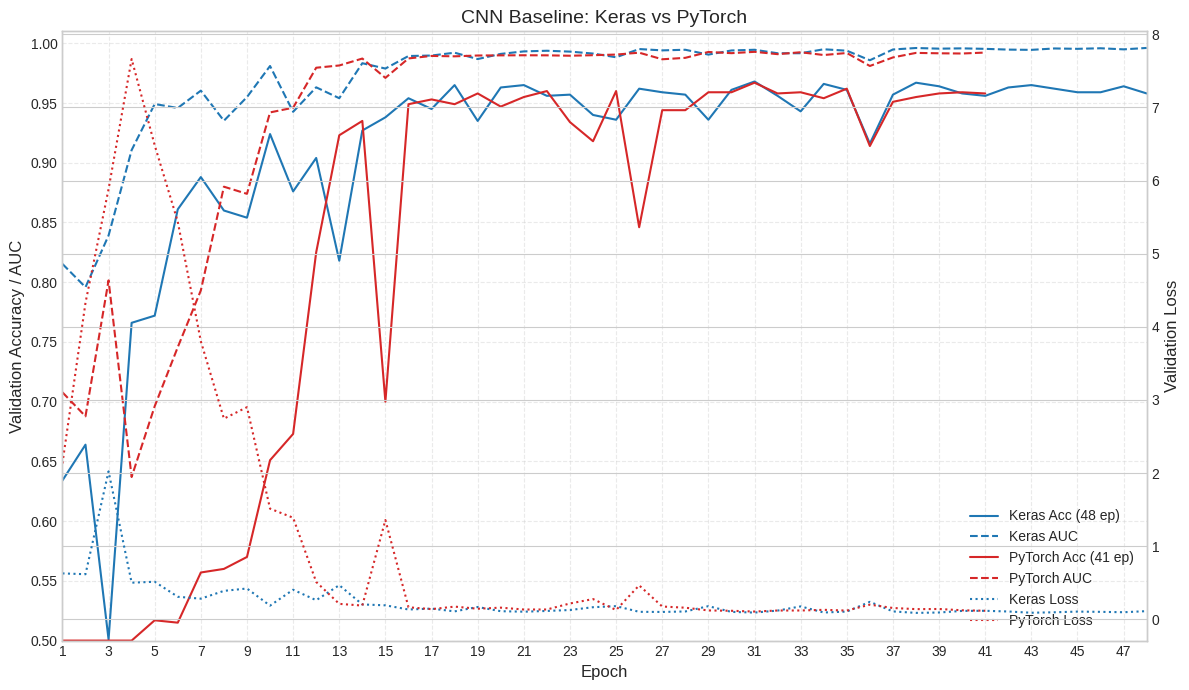

In [3]:
plot_framework_comparison(
    keras_baseline_history,
    torch_baseline_history,
    title="CNN Baseline: Keras vs PyTorch",
    save_path="/kaggle/working/baseline_models_plot.png"
)

### 3.2 CNN–ViT Hybrid: Keras vs PyTorch

**Early phase**

* Same pattern as baseline:

  * PyTorch remains near chance (0.50) for several epochs.
  * Very high initial loss (15.3 → 6.5).
* Keras improves steadily from epoch 1.
* High AUC (>0.93) achieved by:

  * **Epoch 6 (Keras)**
  * **Epoch 12 (PyTorch)**

**Mid training**

* PyTorch hybrid shows pronounced oscillations:

  * Accuracy drops (e.g., 0.71, 0.75) even after reaching >0.94.
  * Loss spikes (e.g., 1.06 at epoch 19, 1.16 at epoch 22).
* Keras hybrid is more stable, though slightly more variable than Keras CNN baseline.

**Late phase**

* Both converge to:

  * Accuracy ≈ 0.96–0.97
  * AUC ≈ 0.994–0.996
* Keras hybrid triggers early stopping earlier than PyTorch hybrid.
* Final performance is marginally higher than CNN baseline.

**Conclusion**

Hybrid models introduce slightly higher optimization variability, especially in PyTorch.
Keras again stabilizes earlier. Final predictive quality is comparable across frameworks.

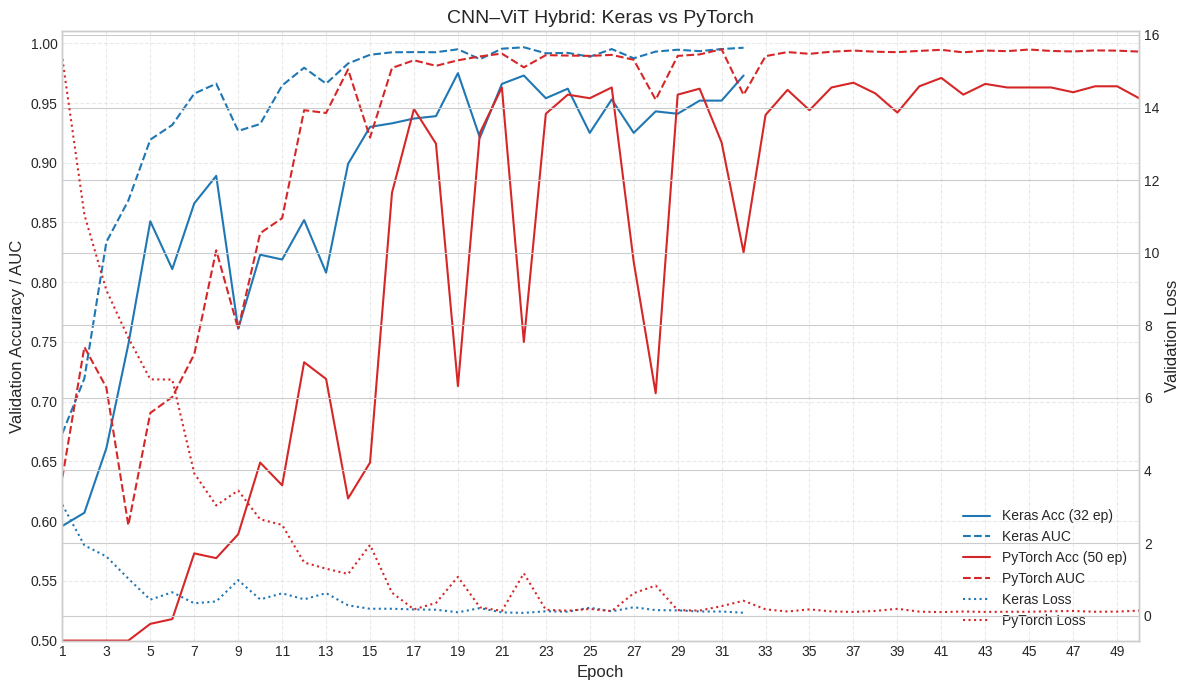

In [4]:
plot_framework_comparison(
    keras_hybrid_history,
    torch_hybrid_history,
    title="CNN–ViT Hybrid: Keras vs PyTorch",
    save_path="/kaggle/working/hybrid_models_plot.png"
)

### 3.3 Architecture Comparison (Baseline vs Hybrid)

**Early stopping ordering**

1. Keras Hybrid
2. PyTorch Baseline
3. Keras Baseline
4. PyTorch Hybrid

**Framework behavior**

* PyTorch models exhibit:

  * Higher early loss
  * More pronounced oscillations
* Keras models show smoother metric trajectories.

**Architecture behavior**

* Hybrid models display:

  * Slightly higher mid-training variability
  * Faster rise in AUC in Keras
* Baseline CNN is marginally more stable during optimization.

**AUC convergence**

* All models stabilize around high AUC (~0.99+) by ~epoch 16.
* Hybrid models reach peak AUC slightly earlier in Keras.

**Loss behavior**

* PyTorch models start with significantly higher loss values.
* After stabilization, all models converge to similar low-loss regimes (~0.08–0.12).

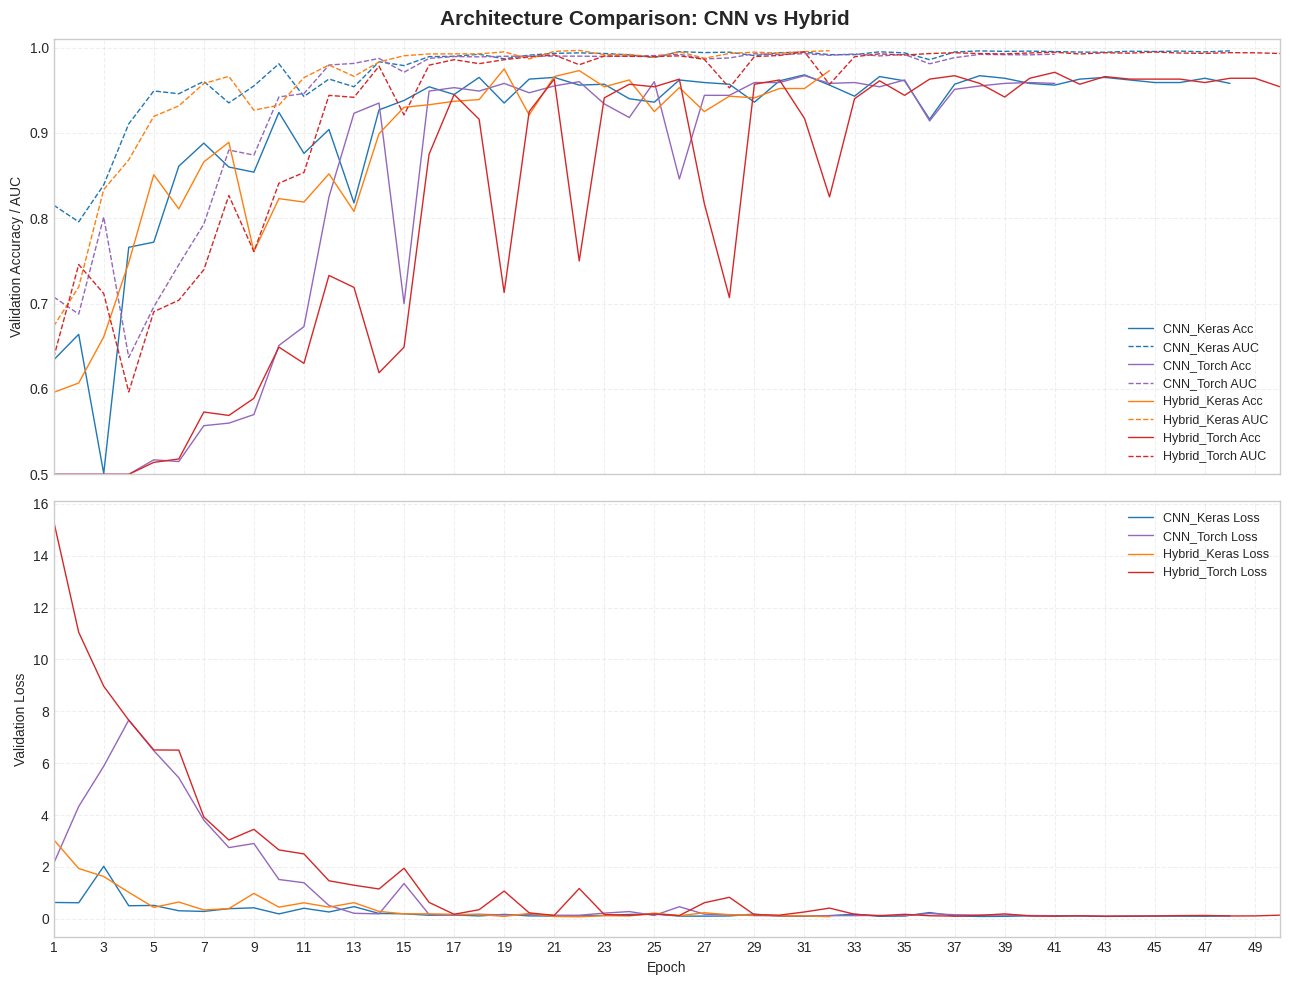

In [5]:
plot_architecture_comparison(
    keras_baseline_history,
    torch_baseline_history,
    keras_hybrid_history,
    torch_hybrid_history,
    title="Architecture Comparison: CNN vs Hybrid",
    save_path="/kaggle/working/architecture_comparison_plot.png"
)

### 3.4 Learning Dynamics Overall Interpretation

* Final predictive performance is very similar across all four models.
* Hybrid architecture provides a small but consistent improvement in peak AUC and loss.
* Framework differences primarily affect:

  * Early optimization stability
  * Oscillation magnitude
  * Convergence smoothness

Performance ranking at convergence is tightly clustered, indicating that architectural capacity and framework implementation influence training dynamics more than final accuracy.

## 4. Generalization Analysis

This section evaluates the generalization gap (train vs validation) across epochs and at the best validation-loss epoch. The focus is stability and overfitting behavior rather than peak accuracy.

### 4.1 Generalization Gap Over Epochs

**Across frameworks**

* PyTorch models exhibit larger oscillations in gap magnitude.
* Keras models show smoother and more progressively shrinking gaps.
* Around epoch ~18, all models reach a relatively low and stable accuracy gap.

**Baseline models**

* Keras baseline stabilizes earlier and maintains a narrow gap after mid-training.
* PyTorch baseline shows visible fluctuations, especially in mid-epochs (consistent with loss spikes).

**Hybrid models**

* Hybrid architectures display slightly higher variability after stabilization.
* PyTorch hybrid shows the strongest oscillatory behavior.
* Keras hybrid stabilizes earlier but still oscillates more than Keras baseline.

**Overall pattern**

* No model shows sustained divergence between training and validation.
* After mid-training, gaps remain small for all models.
* Differences are primarily in stability, not magnitude.

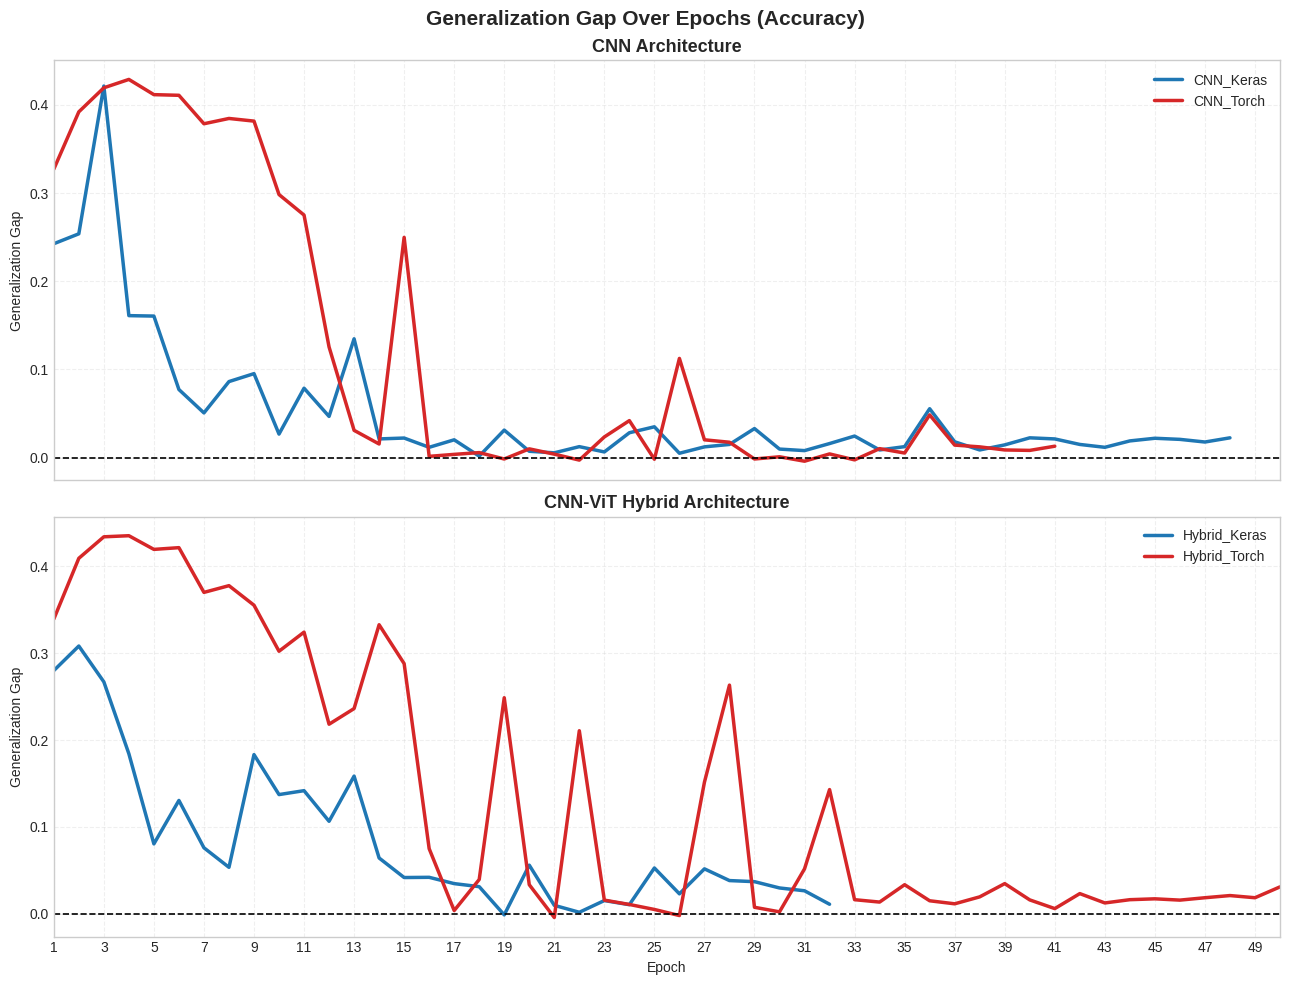

In [6]:
plot_generalization_gap(
    keras_baseline_history,
    torch_baseline_history,
    keras_hybrid_history,
    torch_hybrid_history,
    metric="accuracy",
    title="Generalization Gap Over Epochs",
    save_path="/kaggle/working/generalization_gap_plot.png"
)

### 4.2 Gap at Best Epoch (Table)

| Model        | Best Epoch | Gap (Loss) | Relative Gap % (Loss) | Gap (Acc) | Relative Gap % (Acc) |
| ------------ | ---------- | ---------- | --------------------- | --------- | -------------------- |
| CNN_Keras    | 38         | -0.0253    |        28.96          | 0.0088    |        0.90          |
| CNN_Torch    | 31         | -0.0112    |        10.52          | -0.0040   |       -0.42          |
| Hybrid_Keras | 22         | -0.0072    |        9.61           | 0.0017    |        0.18          |
| Hybrid_Torch | 41         | -0.0420    |        43.42          | 0.0060    |        0.61          |

**Observations**

* **Best overall generalization (most balanced)**: Keras Hybrid

  * Smallest loss gap
  * Very small accuracy gap

* **Largest loss gap**: PyTorch Hybrid

  * Higher relative loss gap despite strong validation accuracy

* **Largest accuracy gap**: Keras Baseline

  * Slightly higher relative accuracy difference

* PyTorch Baseline shows the smallest accuracy gap (slightly negative), indicating near-identical train/validation accuracy at best epoch.

**Interpretation**

* All models generalize well; gaps remain small at optimal epochs.
* Keras Hybrid presents the most consistent balance between fit and generalization.
* PyTorch models tend to exhibit larger loss-gap variability, consistent with their higher metric oscillation during training.
* Architectural differences affect stability more than absolute generalization magnitude.

Overall, overfitting is controlled in all configurations, with differences primarily in convergence smoothness rather than generalization capacity.

In [7]:
compute_gap_at_best_epoch(
    keras_baseline_history,
    torch_baseline_history,
    keras_hybrid_history,
    torch_hybrid_history,
    save_path="/kaggle/working/gap_best_epoch.csv"
)

Gap at Best Epoch (Best = Lowest Validation Loss)



,Best Epoch,Gap (Loss),Rel Gap % (Loss),Gap (Accuracy),Rel Gap % (Accuracy)
CNN_Keras,38,-0.0253,28.96,0.0088,0.90
CNN_Torch,31,-0.0112,10.52,-0.0040,-0.42
Hybrid_Keras,22,-0.0072,9.61,0.0017,0.18
Hybrid_Torch,41,-0.0420,43.42,0.0060,0.61


## 5. Final Performance Comparison

This section consolidates the best-epoch results of the four trained models and compares their metric profiles, error distributions, and decision behavior. The objective is not only to rank performance, but to characterize how each model behaves and how this translates into actual false positives and false negatives predictions.

### 5.1 Final Metrics Table

Key patterns:

* **Highest Accuracy**: Hybrid_Keras (0.973)
* **Highest Precision**: Hybrid_Torch (0.9663), very close to CNN_Torch (0.9661)
* **Highest Recall**: Hybrid_Keras (0.988)
* **Highest F1**: Hybrid_Keras (0.9734)
* **Highest AUC**: Hybrid_Keras (0.9967)
* **Lowest Loss**: Hybrid_Keras (0.0748)
* **Lowest AUC**: CNN_Torch (0.9928)
* **Lowest Loss**: Hybrid_Keras (0.0748)

Architecture effect:

* Hybrid models outperform CNN models in all metrics.
* Precision differences are small and slightly favor PyTorch variants.
* Keras models achieve lower validation loss than their PyTorch counterparts.

In [8]:
final_metrics_df = build_final_metrics_table(
    keras_baseline_history,
    torch_baseline_history,
    keras_hybrid_history,
    torch_hybrid_history,
    save_path="/kaggle/working/final_metrics.csv"
)

final_metrics_df

,Best Epoch,Accuracy,Precision,Recall,F1,AUC,Loss
CNN_Keras,38,0.967,0.9534,0.982,0.9675,0.9960,0.0875
CNN_Torch,31,0.967,0.9661,0.968,0.9670,0.9928,0.1060
Hybrid_Keras,22,0.973,0.9592,0.988,0.9734,0.9967,0.0748
Hybrid_Torch,41,0.971,0.9663,0.976,0.9711,0.9945,0.0967


### 5.2 Final Model Evaluation

* All models are reloaded and evaluated on the same validation split.
* Output probability ranges confirm well-calibrated confidence spread:

  * All models produce probabilities very close to 0 and 1.
  * No saturation or collapsed prediction distribution observed.
* Evaluation confirms training-time metrics are reproducible at inference.

In [9]:
results = evaluate_models(
    cnn_keras_weights=keras_baseline,
    hybrid_keras_weights=keras_hybrid,
    cnn_torch_weights=torch_baseline,
    hybrid_torch_weights=torch_hybrid,
    keras_val_dataset=val_ds_keras,
    torch_val_loader=val_loader,
    build_keras_cnn=build_keras_cnn,
    build_keras_hybrid_model=build_keras_hybrid_model,
    CNNBaseline=CNNBaseline,
    TorchHybridModel=TorchHybridModel
)

# Quick Checking the Evaluation results
for name in results:
    probs = results[name]["y_proba"]
    print(name, probs.min(), probs.max())

I0000 00:00:1772568880.514858      24 cuda_dnn.cc:529] Loaded cuDNN version 91002


CNN_Keras 1.2873915e-07 0.9999993
Hybrid_Keras 4.9439535e-08 0.9999982
CNN_Torch 4.4657544e-09 0.99999976
Hybrid_Torch 2.6424217e-07 1.0


### 5.3 ROC Curve Comparison

AUC values:

* CNN_Keras: **0.9960**

* Hybrid_Keras: **0.9973**

* CNN_Torch: **0.9928**

* Hybrid_Torch: **0.9945**

* All ROC curves follow nearly identical shapes.

* Hybrid models slightly dominate across thresholds.

* Separation between classes is extremely strong in all cases.

* Differences in AUC are marginal but consistent.

CNN_Keras AUC: 0.9960
Hybrid_Keras AUC: 0.9973
CNN_Torch AUC: 0.9928
Hybrid_Torch AUC: 0.9945


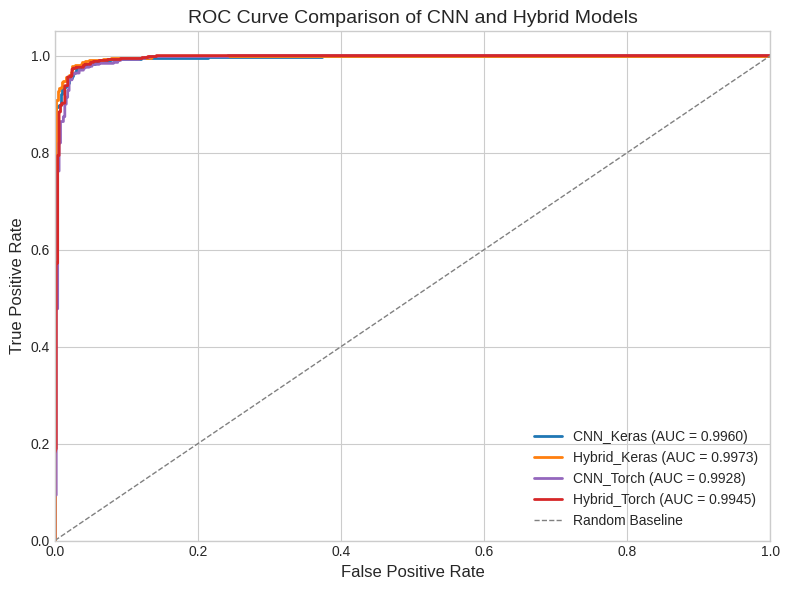

In [10]:
roc_results = compute_roc_from_results(results)

plot_roc_comparison(
    roc_results,
    save_path="/kaggle/working/roc_comparison.png"
)

### 5.4 Confusion Matrix Analysis

**Absolute Correct Predictions (Total samples = 1000)**

| Model        | Correct | Incorrect |
| ------------ | ------- | --------- |
| CNN_Keras    | 967     | 33        |
| CNN_Torch    | 967     | 33        |
| Hybrid_Keras | 973     | 27        |
| Hybrid_Torch | 971     | 29        |

**Observations**

* Hybrid_Keras achieves the highest number of correct predictions (973).
* CNN_Keras and CNN_Torch tie at 967 correct predictions.
* Hybrid_Torch sits in between with 971 correct predictions.

**Error patterns**

* CNN_Keras shows slightly higher false positives.
* CNN_Torch shows more balanced FP/FN.
* Hybrid_Keras reduces false negatives the most (highest recall).
* Hybrid_Torch remains balanced but slightly less optimal than Hybrid_Keras.

Percentage matrices confirm:

* All models maintain ≥95% per-class accuracy.
* Hybrid models slightly improve positive-class detection.

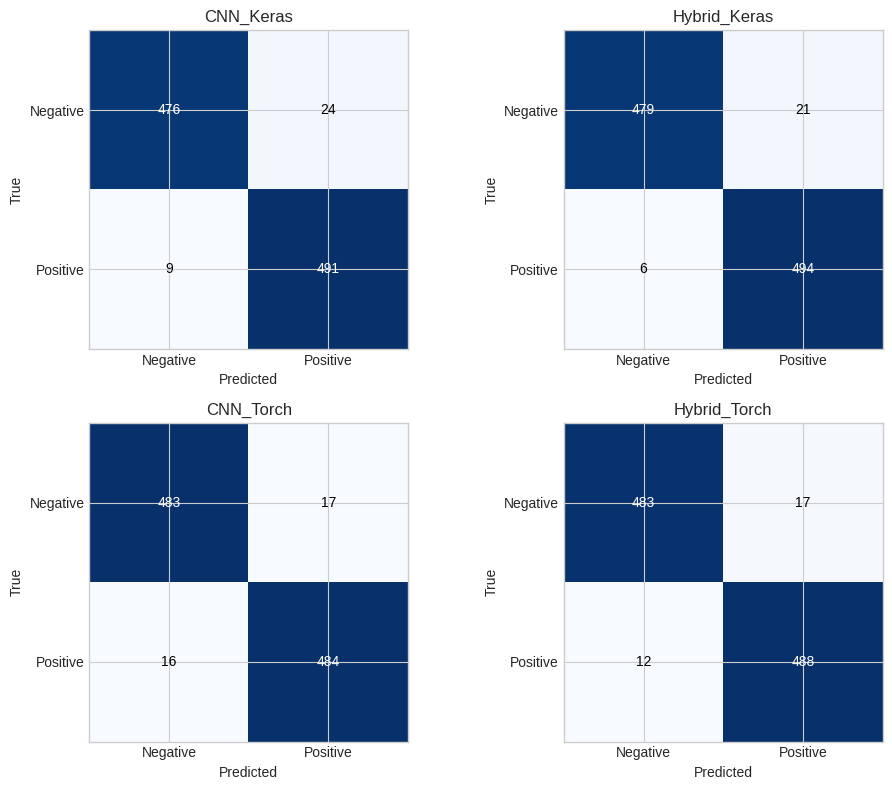

In [ ]:
cm_results = compute_confusion_matrices(results)

plot_confusion_matrix_grid(
    cm_results,
    normalize=False, 
    save_path="/kaggle/working/confusion_matrix_grid_nonorm.png" #Absolute numbers
)

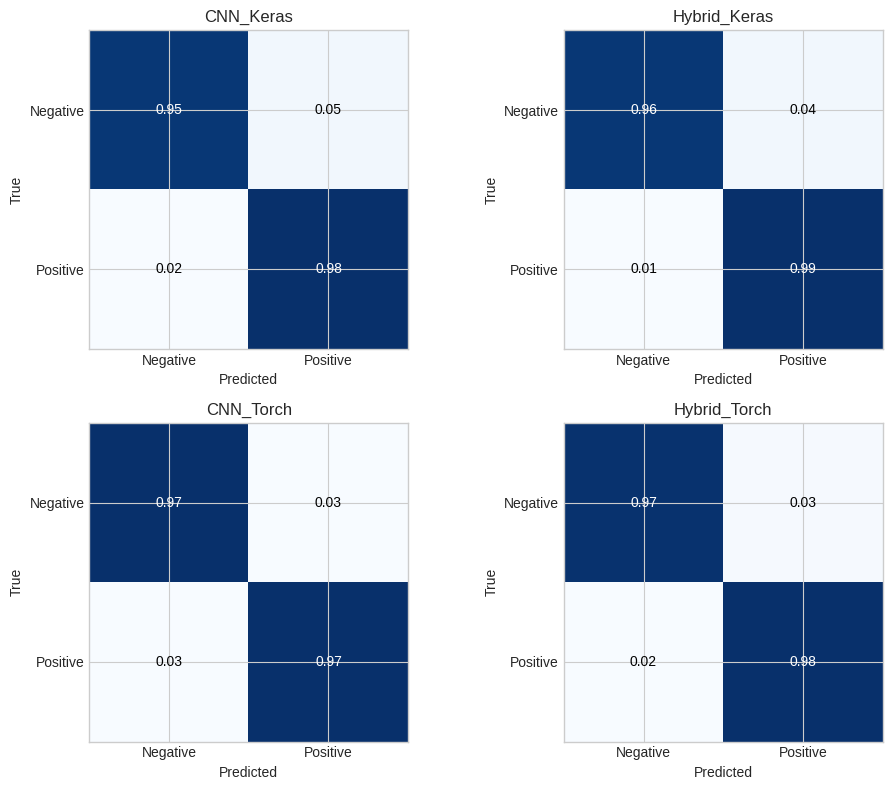

In [ ]:
plot_confusion_matrix_grid(
    cm_results,
    normalize=True, 
    save_path="/kaggle/working/confusion_matrix_grid_norm.png" #Percentages
)

### 5.5 Interpreting Results

#### 5.5.1 Metric-Level Behavioral Profiles

Rather than ranking by a single metric, models can be categorized by prediction tendency. Behavioral categorization is derived strictly from the Precision–Recall relationship.

##### CNN_Keras: Strong Recall-Oriented

* Precision: 0.9534
* Recall: **0.982**

Recall is substantially higher than precision.

**Implications:**

* Aggressive positive prediction.
* Lower False Negatives.
* Higher False Positives relative to other models.
* Suitable when missing positives is more costly than raising false alarms.

##### CNN_Torch: Precision-Leaning Balanced

* Precision: 0.9661
* Recall: 0.968

Precision and Recall are nearly equal, with a very slight recall advantage.

**Implications:**

* Balanced FP/FN tradeoff.
* Fewer False Positives than CNN_Keras.
* Slightly more False Negatives than CNN_Keras.
* More conservative than CNN_Keras, but not strongly precision-biased.

This is the most neutral CNN configuration.

##### Hybrid_Keras: Strongest Recall-Oriented

* Precision: 0.9592
* Recall: **0.988** (highest overall)

Largest Recall–Precision gap among all models.

**Implications:**

* Lowest False Negative rate.
* Increased False Positives compared to precision-leaning models.
* Maximizes positive detection.
* Drives the highest Accuracy and F1 through improved sensitivity.

The hybrid architecture clearly shifts toward stronger positive-class capture.

##### Hybrid_Torch: Precision-Leaning Balanced

* Precision: **0.9663** (highest overall)
* Recall: 0.976

Higher recall than CNN_Torch, but precision remains very strong.

**Implications:**

* Strong True Positive detection.
* Lower False Positives than recall-heavy models.
* More balanced than Hybrid_Keras.
* Provides high recall without sacrificing precision stability.

#### 5.5.2 Behavioral Comparison Summary

| Model        | Orientation                   | FP Tendency  | FN Tendency  | Overall Profile               |
| ------------ | ----------------------------- | ------------ | ------------ | ----------------------------- |
| CNN_Keras    | Recall-heavy                  | Higher       | Lower        | Aggressive positive detection |
| CNN_Torch    | Balanced                      | Moderate-low | Moderate     | Neutral CNN baseline          |
| Hybrid_Keras | Strong recall-heavy           | Moderate     | Lowest       | Most sensitive model          |
| Hybrid_Torch | Balanced / slight recall tilt | Low          | Low-moderate | High-performance compromise   |

##### Structural Insight

* Moving from CNN → Hybrid primarily increases **Recall**.
* Keras models seem more recall oriented, while PyTorch models seem more balanced.
* Precision differences across all four models remain small (within ~0.013 range).
* Recall differences are the main driver of performance separation.

Hybrid_Keras achieves the strongest overall performance because it increases recall significantly while maintaining competitive precision.

#### 5.5.3 Error Distribution Perspective

From confusion matrix totals (1000 samples):

| Model        | Correct | Incorrect |
| ------------ | ------- | --------- |
| CNN_Keras    | 967     | 33        |
| CNN_Torch    | 967     | 33        |
| Hybrid_Keras | 973     | 27        |
| Hybrid_Torch | 971     | 29        |

Interpretation by error type:

* Recall-oriented models (CNN_Keras, Hybrid_Keras):

  * Minimize False Negatives.
  * Accept slightly higher False Positives.

* Precision-oriented model (CNN_Torch):

  * Minimizes False Positives.
  * Accepts slightly higher False Negatives.

* Balanced models (Hybrid_Torch, but also CNN_Torch):

  * Distributes FP and FN more evenly.

The hybrid architectures reduce total error count primarily by improving positive-class detection.

#### 5.5.4 ROC interpretation

AUC values:

* CNN_Keras: 0.9960
* Hybrid_Keras: 0.9973
* CNN_Torch: 0.9928
* Hybrid_Torch: 0.9945

Observations:
* All models achieve near-perfect separability.
* Differences in AUC (~0.002–0.004) indicate subtle improvements in ranking quality rather than dramatic threshold behavior changes.
* Hybrid architectures improve margin separation consistency.

#### 5.5.5 Confusion Matrix Implications

On a dataset of 1,000 samples:

* Best (Hybrid_Keras) vs baseline difference = **6 additional correct predictions** (973 vs 967).

If scaled:

* On 100,000 samples → ~600 additional correct predictions.
* On 1,000,000 samples → ~6,000 additional correct predictions.

Although percentage differences appear small (~0.6%), absolute impact scales linearly with dataset size.

#### 5.5.6 Architecture Effect

* Hybrid models improve recall more than precision.
* Attention component likely enhances discrimination of harder samples.
* Baseline CNN already performs strongly; hybrid adds incremental but measurable gains.

#### 5.5.7 Framework Effect

* Keras implementations slightly outperform PyTorch in final metrics.
* Differences are small and within reproducibility tolerance.
* No structural divergence in model behavior.

#### 5.5.8 Practical Interpretation

If minimizing False Negatives is critical:

* Hybrid_Keras is most appropriate.

If minimizing False Positives is critical:

* CNN_Torch is slightly preferable.

If a balanced tradeoff is required:

* Hybrid_Torch provides strong overall stability.

Although metric differences are small (≤0.6% accuracy spread), they translate into meaningful differences at scale. The hybrid architecture consistently improves recall and total correct predictions while maintaining high precision.

Overall:

* All four models are high-performing.
* Hybrid models improve sensitivity.
* Framework differences are secondary to architectural effects.
* Hybrid_Keras presents the strongest overall performance profile in this evaluation.


## 6. Efficiency & Computational Cost

This section compares architectural complexity, training efficiency, storage footprint, and the performance–efficiency tradeoff across the four models.

### 6.1 Parameter Count Comparison

Parameter counts:

* **CNN_Keras:** 456,673
* **Hybrid_Keras:** 795,617
* **CNN_Torch:** 455,291
* **Hybrid_Torch:** 794,145

**Observations**

* Hybrid models have ~74% more parameters than their CNN counterparts.
* Parameter counts are nearly identical across frameworks for equivalent architectures.
* Architectural choice (CNN vs Hybrid) drives complexity, not framework.

Conclusion: The hybrid architecture substantially increases representational capacity.

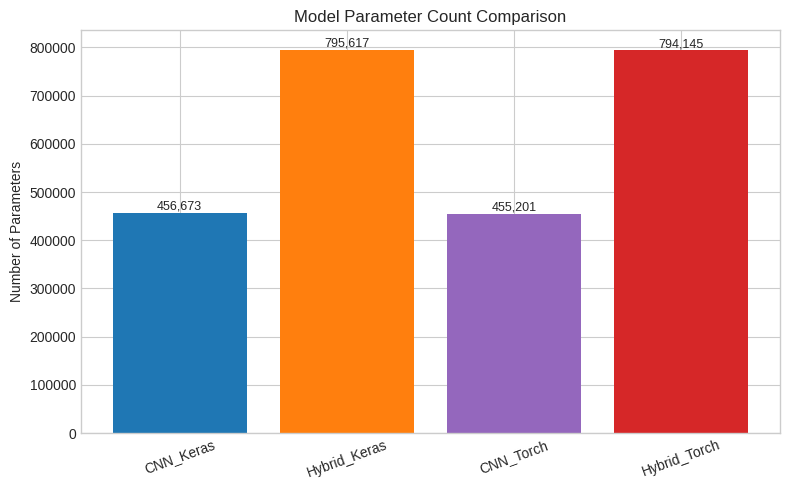

In [13]:
param_counts = compute_parameter_counts(
    build_keras_cnn,
    build_keras_hybrid_model,
    CNNBaseline,
    TorchHybridModel
)

plot_parameter_comparison(
    param_counts,
    save_path="/kaggle/working/parameter_comparison.png"
)

### 6.2 Training Time Comparison

Training times:

* **CNN_Keras:** 12.38 minutes
* **Hybrid_Keras:** 8.28 minutes
* **CNN_Torch:** 4.65 minutes
* **Hybrid_Torch:** 4.36 minutes

**Observations**

* PyTorch models train significantly faster than Keras models.
* Hybrid_Torch is the fastest overall.
* CNN_Keras is the slowest despite having fewer parameters than hybrid variants.
* Hybrid_Keras trains faster than CNN_Keras due to earlier convergence (fewer epochs).

Conclusion: Framework implementation impacts training time more than parameter count.

CNN_Keras: 12.38 minutes
Hybrid_Keras: 8.28 minutes
CNN_Torch: 4.65 minutes
Hybrid_Torch: 4.36 minutes


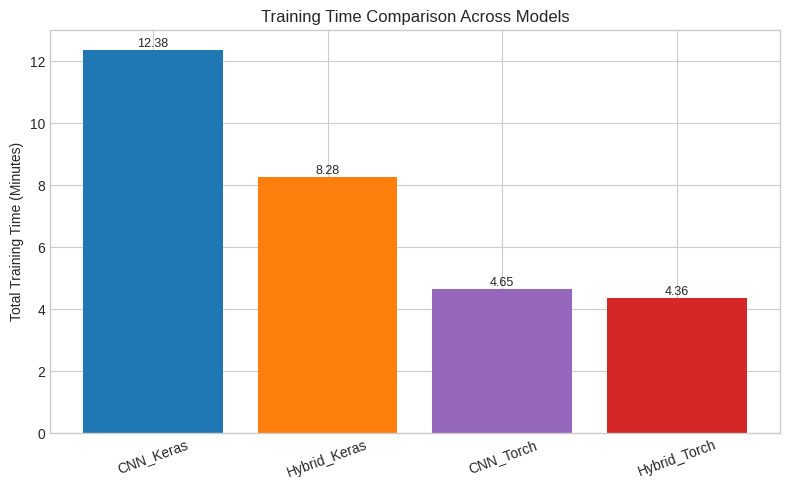

In [14]:
json_paths = {
    "CNN_Keras": "/kaggle/input/datasets/filipebraiman/baseline-models-training-info/keras_cnn_baseline_metadata.json",
    "Hybrid_Keras": "/kaggle/input/datasets/filipebraiman/hybrid-models-training-info/keras_hybrid_metadata.json",
    "CNN_Torch": "/kaggle/input/datasets/filipebraiman/baseline-models-training-info/pytorch_cnn_baseline_metadata.json",
    "Hybrid_Torch": "/kaggle/input/datasets/filipebraiman/hybrid-models-training-info/pytorch_hybrid_metadata.json"
}

metadata = load_training_metadata(json_paths)
training_times = extract_training_times(metadata)

plot_training_time_comparison(
    training_times,
    save_path="/kaggle/working/training_time_comparison.png"
)

### 6.3 Model Size Comparison

Saved model sizes:

* **CNN_Keras:** 5.31 MB
* **Hybrid_Keras:** 9.29 MB
* **CNN_Torch:** 1.75 MB
* **Hybrid_Torch:** 3.05 MB

**Observations**

* Hybrid models require ~1.7–1.8× more storage than CNN models.
* PyTorch models are significantly smaller on disk than Keras equivalents.
* Storage scales proportionally with parameter count.

Conclusion: Hybrid_Keras is the largest model; CNN_Torch is the most storage-efficient.

CNN_Keras: 5.31 MB
Hybrid_Keras: 9.29 MB
CNN_Torch: 1.75 MB
Hybrid_Torch: 3.05 MB


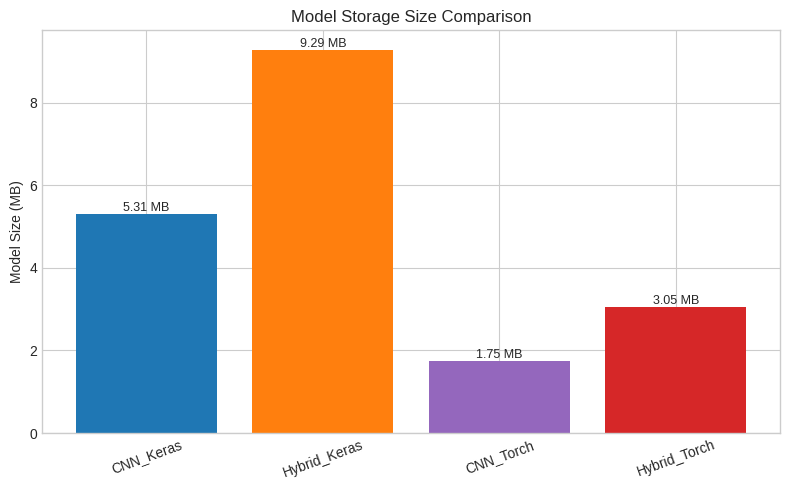

In [15]:
model_sizes = extract_model_sizes(metadata)

plot_model_size_comparison(
    model_sizes,
    save_path="/kaggle/working/model_size_comparison.png"
)

### 6.4 Performance vs Efficiency Tradeoff

#### 6.4.1 AUC vs Parameter Count

**Observed pattern**

* **Hybrid_Keras:** Highest AUC with one of the highest parameter counts and moderate training time.
* **Hybrid_Torch:** Similar parameter count, slightly lower AUC, fastest training.
* **CNN_Keras:** Second-best AUC with considerably fewer parameters but longest training time.
* **CNN_Torch:** Lowest parameter count among hybrids and lower AUC, but very fast training.

Interpretation:

* Increasing parameters (CNN → Hybrid) improves AUC.
* Keras achieves slightly higher AUC than Torch at comparable parameter counts.
* Training time does not scale strictly with parameter count.

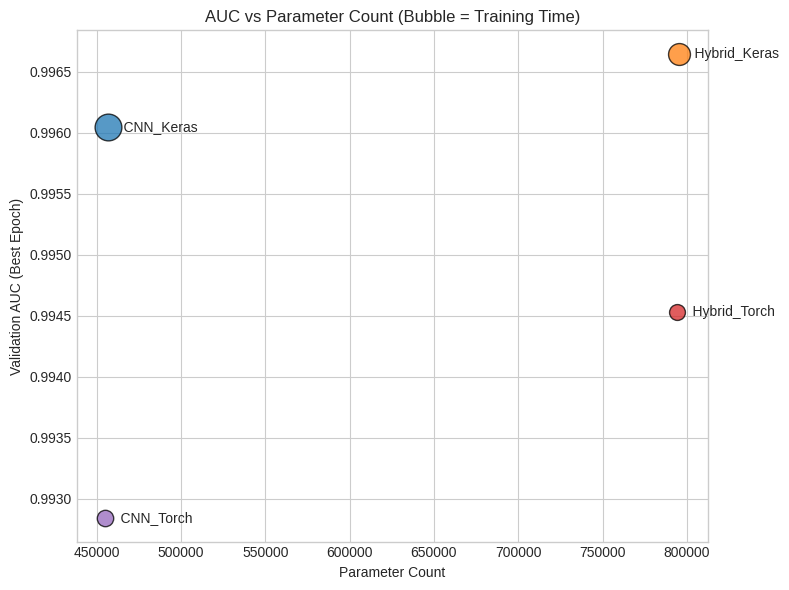

In [16]:
tradeoff_metrics = build_tradeoff_metrics(models_info)

plot_auc_vs_params(tradeoff_metrics, save_path="/kaggle/working/auc_vs_params.png")

#### 6.4.2 Accuracy vs Training Time

**Observed pattern**

* **Hybrid_Torch:** Best training time with second-best accuracy.
* **Hybrid_Keras:** Best accuracy with moderate training time.
* **CNN_Torch:** Fast but lower accuracy than hybrids.
* **CNN_Keras:** Longest training time with lower accuracy than hybrids.

Interpretation:

* PyTorch variants dominate on efficiency.
* Hybrid architectures dominate on accuracy.
* CNN_Keras is the least efficient configuration (longest time without top accuracy).

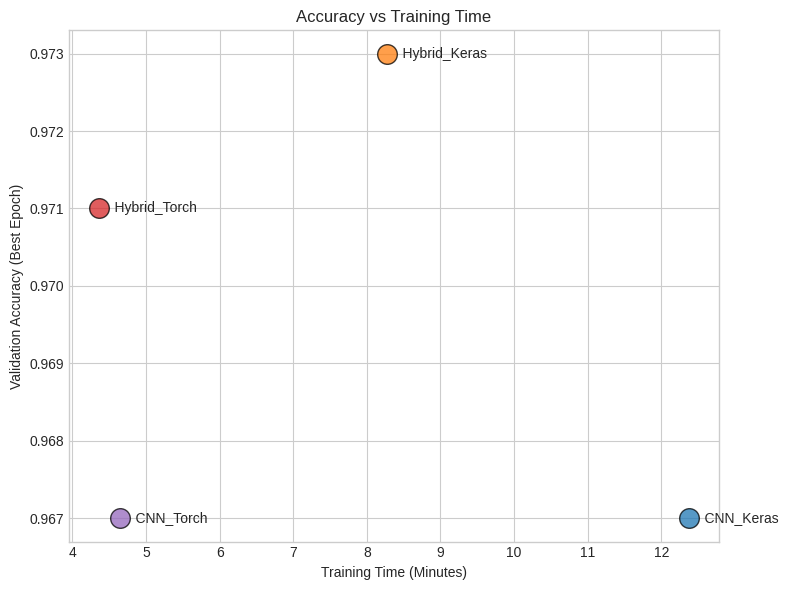

In [17]:
plot_accuracy_vs_time(tradeoff_metrics, save_path="/kaggle/working/accuracy_vs_time.png")

#### 6.4.3 AUC vs Model Size

**Observed pattern**

* Torch models: smaller size, faster training, slightly lower AUC.
* Hybrid_Keras: largest model size, best AUC, moderate training time.
* CNN_Keras: mid-sized model, high AUC, longest training time.

Interpretation:

* Larger model size correlates with higher AUC.
* PyTorch provides better storage efficiency.
* Hybrid_Keras occupies the high-performance / high-capacity region.

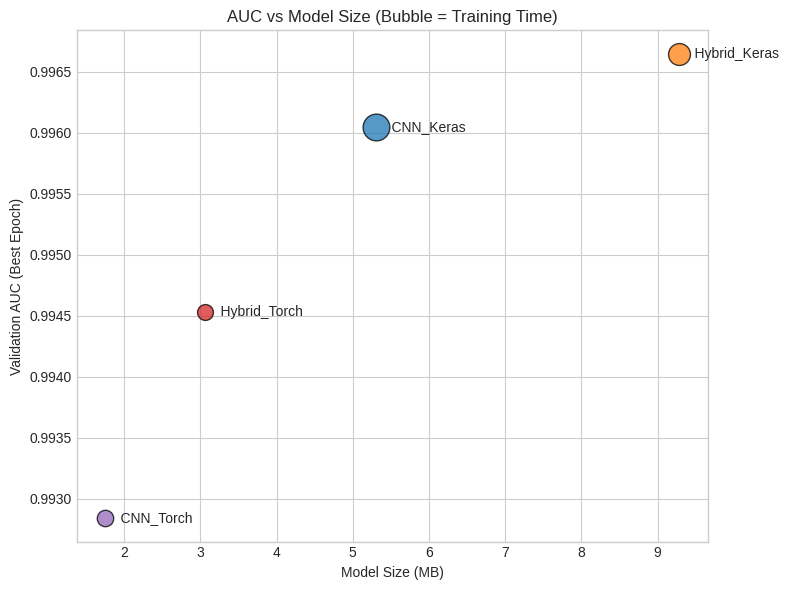

In [18]:
plot_auc_vs_model_size(tradeoff_metrics, save_path="/kaggle/working/auc_vs_model_size.png")

## 7. Cross-Dimension Analysis

This section isolates the impact of framework choice (Keras-TensorFlow vs PyTorch) and architecture choice (CNN vs Hybrid), and evaluates whether their effects are independent or interacting.

### 7.1. Framework Effect

**Performance**

* Keras models achieve slightly higher **AUC** and lower **validation loss**.
* Accuracy differences between frameworks are small.
* Precision is marginally higher in PyTorch variants.

**Training Behavior**

* Keras shows smoother convergence.
* PyTorch exhibits more metric oscillation.
* Both frameworks converge to similar final performance ranges.

**Efficiency**

* PyTorch trains significantly faster (≈2–3×).
* PyTorch models are substantially smaller on disk.
* Parameter counts are nearly identical across frameworks for the same architecture.

**Framework Summary**

* Keras → slightly stronger final metrics, smoother optimization.
* PyTorch → superior computational efficiency (training time and storage).
* Performance differences are small; efficiency differences are substantial.

### 7.2. Architecture Effect

**Performance Impact**

Moving from pure CNN to CNN-ViT Hybrid:

* Accuracy increases (~+0.4% to +0.6%).
* Recall consistently increases.
* F1 and AUC improve.
* Loss decreases (notably in Keras).

**Behavioral Shift**

* Hybrid models are more recall-oriented.
* False Negatives decrease.
* Slight increase in False Positives in recall-heavy configurations.
* Decision boundary shifts toward stronger positive detection.

**Complexity Impact**

* ~74% increase in parameter count.
* ~70–80% increase in model size.
* Training time does not increase proportionally (and may decrease due to earlier convergence).

**Architecture Summary**

* Hybrid architecture provides consistent performance gains.
* Gains are incremental but systematic.
* Cost increase is primarily in parameters and storage, not necessarily training time.

### 7.3. Interaction Effect

The interaction between framework and architecture shows the following patterns:

* Hybrid improvements occur in both frameworks.
* Keras amplifies the performance ceiling of the Hybrid model (highest AUC and accuracy).
* PyTorch amplifies efficiency advantages, even for larger hybrid models.
* Behavioral orientation (recall-heavy vs balanced) is primarily architecture-driven.

**Combined Outcomes**

* Hybrid_Keras → highest predictive performance.
* Hybrid_Torch → best performance–efficiency compromise.
* CNN_Torch → most computationally efficient baseline.
* CNN_Keras → strong performance but weakest efficiency profile.

**Overall Interpretation**

* Architecture choice has a larger impact on predictive performance.
* Framework choice has a larger impact on computational efficiency.
* Their effects are largely additive rather than conflicting.

In practical terms:

* Choose **Hybrid** for performance optimization.
* Choose **PyTorch** for computational efficiency.
* Choose **Hybrid_Keras** when maximum predictive quality is the priority.

## 8. Discussion

This section synthesizes the performance, generalization, and efficiency findings to provide an integrated interpretation of the results and practical implications.

### 8.1. Predictive Performance Summary

All four models achieve very strong classification performance, with AUC values above 0.99 and accuracy between 0.967 and 0.973. The baseline CNN architectures already provide highly reliable class separation, indicating that the dataset is well-structured for convolutional feature extraction.

The hybrid models consistently outperform the CNN baselines across Accuracy, Recall, F1, and AUC. The most significant improvement is observed in Recall, where the hybrid architectures reduce false negatives and improve sensitivity to positive samples. Among all configurations, Hybrid_Keras achieves the highest Accuracy (0.973), highest Recall (0.988), highest F1 (0.9734), and highest AUC (0.9967), representing the strongest overall predictive performance.

Precision differences across models are relatively small. Hybrid_Torch and CNN_Torch achieve the highest precision values, but the margin is narrow and does not substantially alter overall ranking. The main driver of performance separation is recall improvement rather than precision gain.

Overall, architectural enhancement (CNN → Hybrid) has a larger effect on predictive performance than framework choice (Keras vs PyTorch).

### 8.2. Generalization Behavior

All models demonstrate controlled generalization behavior, with small gaps between training and validation metrics at their best epochs. No configuration shows sustained divergence indicative of severe overfitting.

Keras implementations exhibit smoother convergence curves and more stable validation refinement during later epochs. PyTorch implementations show slightly more oscillation during training, but this does not translate into degraded final generalization performance.

Hybrid_Keras presents the most balanced generalization profile, combining low validation loss with minimal performance gap at the optimal epoch. Hybrid_Torch shows slightly larger loss-gap variability but still maintains strong validation stability.

Across all models, the generalization differences are subtle. The results suggest that training configuration and regularization strategies are adequate in both frameworks, and that the hybrid architecture does not introduce instability despite its increased complexity.

### 8.3. Efficiency Tradeoffs

The hybrid architecture increases parameter count by approximately 74% and model size by roughly 70–80% compared to the CNN baseline. This reflects the added representational capacity of the attention-based components.

However, the increase in parameter count does not proportionally increase training time. In fact, Hybrid_Keras trains faster than CNN_Keras due to earlier convergence, and Hybrid_Torch is the fastest configuration overall. This indicates that convergence dynamics play a larger role in training duration than raw parameter count.

Framework differences are more pronounced in efficiency than in predictive performance. PyTorch models train approximately two to three times faster and produce substantially smaller saved models. Keras models, while slightly slower and larger, achieve marginally better peak metrics.

The performance gains from the hybrid architecture are incremental but consistent. Given that all models already operate in a high-performance regime (AUC > 0.99), improvements represent refinements rather than dramatic shifts in capability.

### 8.4. Practical Recommendation

If the primary objective is maximum predictive performance with minimal false negatives, Hybrid_Keras is the strongest choice. It provides the highest accuracy, best AUC, and strongest recall while maintaining stable generalization.

If computational efficiency is a priority—particularly training speed and storage footprint—Hybrid_Torch offers the best tradeoff between performance and resource usage. It achieves near-top accuracy and AUC with significantly reduced training time and model size.

For constrained environments where simplicity and minimal resource usage are critical, CNN_Torch provides the most efficient baseline with competitive performance.

In summary, architecture selection primarily determines predictive strength, while framework selection primarily determines computational efficiency. The optimal configuration depends on whether the application prioritizes marginal performance gains or resource optimization.

## 9. Limitations

Although strong care was taken to ensure equivalence across frameworks, exact computational parity is not fully attainable. The Keras and PyTorch implementations were designed to mirror architecture, hyperparameters, optimizer settings, learning rate scheduling, and data splits as closely as possible. However, minor differences may remain due to framework-specific defaults, internal numerical implementations, backend libraries, and low-level computation order.

Data augmentation pipelines were aligned conceptually, but implementation-level differences (e.g., interpolation methods, randomness handling, or preprocessing internals) can introduce small variations in effective training data distribution. Similarly, floating-point precision behavior, weight initialization nuances, and GPU execution order may lead to slight divergence in optimization trajectories.

Training time comparisons are also environment-dependent. Although all experiments were conducted under consistent conditions, hardware scheduling, backend optimizations, and framework execution models influence runtime measurements.

Importantly, this study aims to compare frameworks and architectures under equivalent real-world usage conditions, not to enforce bit-level reproducibility. Achieving deterministic, bit-for-bit equivalence across deep learning frameworks is not feasible in this setting. Instead, the objective was methodological rigor: controlled splits, matched hyperparameters, aligned architectures, and reproducible evaluation procedures.

Finally, performance differences are measured on a single dataset. While results are internally consistent, generalization to other datasets or domains may vary depending on data complexity, scale, and class distribution.

These limitations are expected in cross-framework empirical comparisons and do not invalidate the findings, but they contextualize the observed differences.


## 10. Conclusion

This project set out to systematically compare CNN and hybrid CNN-ViT architectures across Keras (TensorFlow) and PyTorch frameworks, focusing on a binary classification task of distinguishing annual versus permanent crop images from the EuroSAT dataset. This application has clear real-world relevance for precision agriculture, crop monitoring, and land-use planning, where accurate classification of crop types can support decision-making at scale. The aim was to assess predictive performance, generalization behavior, and computational efficiency in a controlled, reproducible setting.

The study was structured to align architectures, hyperparameters, data splits, and training procedures as closely as possible, while acknowledging minimal unavoidable differences arising from framework-specific implementations and backend computation. The analysis progressed through evaluation of validation metrics, generalization gaps, ROC curves, confusion matrices, and efficiency tradeoffs.

Key findings indicate that hybrid models consistently achieve higher recall and AUC, with Keras variants showing slightly lower loss, while PyTorch models provide faster training and smaller model sizes. Despite small differences, all models reached high levels of predictive performance, demonstrating the robustness of both frameworks for real-world use cases in crop classification.

This work establishes a baseline for fair cross-framework comparison and opens avenues for future experimentation. Potential directions include evaluating the impact of different random seeds, testing on alternative datasets, or introducing additional architectures to explore broader performance landscapes.

I thank the reader for following this project and formally conclude that the study provides a rigorous, reproducible framework for analyzing model and framework effects in applied deep learning for agricultural image classification.


## Author
**Filipe Braiman Carvalho**  
Applied AI & LLM Systems | Deep Learning · Transformers · RAG · Computer Vision | End-to-End ML Engineering

**Email:** [filipebraiman@gmail.com](mailto:filipebraiman@gmail.com)  
**LinkedIn:** [linkedin.com/in/filipe-b-carvalho](https://www.linkedin.com/in/filipe-b-carvalho)  
**GitHub:** [github.com/filipe-braiman](https://github.com/filipe-braiman)  

### About Me  
AI and data professional with experience in **LLM evaluation, retrieval-augmented generation (RAG), and AI model validation**. Currently working in **AI R&D at Huawei as an AI Evaluation Specialist**, contributing to the reliability and real-world performance of LLM and RAG systems. Strong background in **Python-based data and AI workflows**, including model assessment, dataset development, and analytical reporting for production-oriented AI solutions. Portfolio projects explore **deep learning architectures, computer vision, RAG systems, and applied machine learning experimentation**, emphasizing reproducible ML pipelines and practical AI engineering.

## Version History

| Version | Date       | Changes                                |
| :------ | :--------- | :------------------------------------- |
| 1.0     | 2026-03-08 | First publication of the notebook.     |